# ENVIRONMENT MATCHING

In [2]:
import numpy as np
import freud
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# ═════════════════════════════════════════════════════════════
# CONFIGURATION JANUS
# ═════════════════════════════════════════════════════════════

TRAJ_FILE = "trayectoria.xyz"

INTERLAYERS = [
    (16, 'interlayer_top'),
    (15, 'interlayer_mid'),
    (14, 'interlayer_bot'),
]

# Parámetros Environment Clustering
NUM_NEIGHBORS = 3       # 6 vecinos para redes pseudo-hexagonales (Sodio)
MATCH_THRESHOLD = 1.6  # Tolerancia de coincidencia
FRAME_TO_PLOT = -1      # Frame que queremos graficar (-1 = el último)

# ═════════════════════════════════════════════════════════════
# LECTURA DE DATOS
# ═════════════════════════════════════════════════════════════

def read_xyz_trajectory(filepath):
    frames = []
    with open(filepath, 'r') as f:
        while True:
            line = f.readline()
            if not line: break
            n_atoms = int(line.strip())
            comment = f.readline().strip()
            coords, types = [], []
            for _ in range(n_atoms):
                p = f.readline().split()
                coords.append([float(p[1]), float(p[2]), float(p[3])])
                types.append(int(p[4]))
            frames.append((np.array(coords, dtype=float), np.array(types, dtype=int), comment))
    return frames

def parse_box():
    Lx, Ly, Lz = 19.7278442383, 17.0807762146, 200.0000000000
    xy_tilt = 9.8615932465
    xy = xy_tilt / Ly if Ly else 0.0
    return freud.box.Box(Lx=Lx, Ly=Ly, Lz=Lz, xy=xy, xz=0, yz=0)

# ═════════════════════════════════════════════════════════════
# FUNCIONES ADAPTADAS DEL TUTORIAL
# ═════════════════════════════════════════════════════════════

def get_cluster_arr(system, num_neighbors, threshold, registration=False):
    """Adaptado a freud v3.x para el sistema Janus."""
    
    # El diccionario de vecinos se mantiene igual
    cluster_neighbors = dict(
        mode='nearest', 
        num_neighbors=num_neighbors, 
        exclude_ii=True
    )

    match = freud.environment.EnvironmentCluster()
    match.compute(
        system=system,
        threshold=threshold,
        cluster_neighbors=cluster_neighbors,
        registration=registration,
    )
    
    # CORRECCIÓN: Los atributos correctos son cluster_idx y cluster_environments
    return match.cluster_idx, match.cluster_environments
    
def color_by_clust(cluster_index_arr, no_color_thresh=2, no_color="#cccccc", cmap=plt.get_cmap("viridis")):
    """Asigna colores hex a los dominios cristalinos."""
    cluster_counts = Counter(cluster_index_arr)
    
    color_dict = {
        cluster_id: counter
        for counter, (cluster_id, _) in enumerate(cluster_counts.most_common())
    }

    for cluster_id in cluster_counts:
        if cluster_counts[cluster_id] <= no_color_thresh:
            color_dict[cluster_id] = -1
            
    # Protección si todo está desordenado
    max_idx = max(color_dict.values()) if color_dict else -1
    max_idx = max(0, max_idx)
    
    OP_arr = np.linspace(0.0, 1.0, max_idx + 1)

    for old_cluster_index, new_cluster_index in color_dict.items():
        if new_cluster_index == -1:
            color_dict[old_cluster_index] = no_color
        else:
            color_dict[old_cluster_index] = cmap(OP_arr[new_cluster_index])

    return color_dict

# ═════════════════════════════════════════════════════════════
# EJECUCIÓN Y VISUALIZACIÓN
# ═════════════════════════════════════════════════════════════

# ═════════════════════════════════════════════════════════════
# EJECUCIÓN Y VISUALIZACIÓN MULTI-FRAME
# ═════════════════════════════════════════════════════════════

def analyze_and_plot_all():
    print(f"Leyendo {TRAJ_FILE}...")
    frames = read_xyz_trajectory(TRAJ_FILE)
    box = parse_box()
    
    # Creamos una carpeta nueva para no mezclar
    out_dir = Path("resultados_animacion")
    out_dir.mkdir(exist_ok=True)

    print(f"Generando gráficas para {len(frames)} frames. Esto tomará un momento...")

    # AHORA SÍ: Un bucle que recorre todos los frames
    for frame_idx, (coords, types, _) in enumerate(frames):
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
        fig.suptitle(f"Dominios Cristalinos Locales - Frame {frame_idx}", fontsize=16)

        for ax, (type_id, region_name) in zip(axes, INTERLAYERS):
            # 1. Filtrar los átomos de la capa actual
            mask = (types == type_id)
            layer_coords = coords[mask].astype(np.float32)
            
            if len(layer_coords) <= NUM_NEIGHBORS:
                ax.set_title(f"{region_name}\n(Sin suficientes átomos)")
                continue
                
            # 2. Calcular los clusters
            cluster_indices, _ = get_cluster_arr(
                system=(box, layer_coords), 
                num_neighbors=NUM_NEIGHBORS, 
                threshold=MATCH_THRESHOLD, 
                registration=True
            )

            # --- Añade esto para investigar ---
            #unique_clusters = np.unique(cluster_indices)
            #cluster_counts = Counter(cluster_indices)
            #print(f"Frame {frame_idx} - {region_name}:")
            #print(f"  Número de clústeres encontrados: {len(unique_clusters)}")
            #print(f"  Tamaño del clúster más grande: {max(cluster_counts.values())}")
            # ----------------------------------
            # 3. Obtener colores (grupos < 5 se vuelven grises)
            color_dict = color_by_clust(cluster_indices, no_color_thresh=0, no_color="#d3d3d3")
            colors = [color_dict[i] for i in cluster_indices]
            
            # 4. Graficar (Vista Top-Down)
            wrapped_coords = box.wrap(layer_coords)
            ax.scatter(wrapped_coords[:, 0], wrapped_coords[:, 1], c=colors, s=40, edgecolors='k', linewidth=0.5)
            
            ax.set_title(f"{region_name}")
            ax.set_xlabel("X")
            if ax == axes[0]:
                ax.set_ylabel("Y")
            ax.set_aspect('equal')
            ax.grid(alpha=0.3)

        plt.tight_layout()
        
        # Guardamos la imagen numerada (000, 001, ..., 250)
        # Bajamos el DPI a 150 para que el proceso sea rápido y no llene tu disco duro
        filename = out_dir / f"frame_{frame_idx:03d}.png"
        plt.savefig(filename, dpi=150)
        
        # IMPORTANTE: Cerramos la figura para liberar la memoria RAM
        plt.close(fig) 
        
        # Imprimimos el progreso cada 25 frames
        if (frame_idx + 1) % 25 == 0:
            print(f"Progreso: {frame_idx + 1} / {len(frames)} frames guardados...")

    print(f"\n¡Éxito! Las {len(frames)} gráficas están listas en la carpeta: {out_dir}")

if __name__ == "__main__":
    analyze_and_plot_all()

Leyendo trayectoria.xyz...
Generando gráficas para 200 frames. Esto tomará un momento...
Progreso: 25 / 200 frames guardados...
Progreso: 50 / 200 frames guardados...
Progreso: 75 / 200 frames guardados...
Progreso: 100 / 200 frames guardados...
Progreso: 125 / 200 frames guardados...
Progreso: 150 / 200 frames guardados...
Progreso: 175 / 200 frames guardados...
Progreso: 200 / 200 frames guardados...

¡Éxito! Las 200 gráficas están listas en la carpeta: resultados_animacion


# Analisis de el emparejamiento de entorno

Aplicar exactamente esta metodología de emparejamiento de entornos a los átomos de Sodio (Na) a lo largo de 200 *frames* da una ventana directa a la **dinámica y el estado de fase** de iones de Na.

### 1. Orden vs. Movilidad (Fase sólida vs. líquida)

El sodio intercalado no siempre se queda quieto; dependiendo de la temperatura y el espacio, puede formar un "hielo" 2D o comportarse como un fluido.

* **Si existen grandes continentes (morados/azules):** El sodio ha encontrado posiciones estables de mínima energía y ha formado una red cristalina bidimensional sólida. Su movilidad es muy baja.
* **Si existen "confeti" (muchos colores distintos, fragmentos pequeños y puntitos amarillos aislados):** El sodio está altamente desordenado. Esto indica una fase fluida o amorfa donde los iones se están moviendo constantemente de un sitio a otro, sin lograr anclarse en una estructura cooperativa a largo alcance.

### 2. Transiciones de Fase y Cinética (La película de 200 frames)

Tener 200 *frames* permite ver la evolución temporal. La clave aquí es observar **qué tan rápido cambian los colores**:

* **Coalescencia y Cristalización:** Si en los primeros *frames* se observan muchos fragmentos pequeños, y con el paso del tiempo ves cómo se "comen" unos a otros hasta formar un solo continente oscuro, se presencia directamente la cristalización del sodio en tiempo real.
* **Estabilidad Térmica:** Si los dominios grandes "parpadean", cambiando sus frontera  ligeramente pero manteniendo su forma general, se observa una vibración térmica. Si de repente un continente grande se rompe en pedazos de colores, existe un evento de fusión local (melting).

### 3. El Efecto "Molde" de los Aminobencenos

Los grupos aminobenceno son "estorbos" estéricos (bultos) anclados a las capas de carbono.

* **Zonas de frustración:** Es muy probable que los aminobencenos rompan la simetría ideal que el sodio quiere formar. Si ocurre que las fronteras de grano (los bordes donde chocan colores distintos) o los puntitos amarillos aislados aparecen siempre en ciertas zonas, se podria superponer esta gráfica con las posiciones de los aminobencenos.
* 
### 4. Asimetría del Material Janus (Top vs. Mid vs. Bot)

Al comparar las tres gráficas simultáneas, puedes evaluar cómo el confinamiento afecta a cada región.

* **Diferencias de capa:** Es común en sistemas multicapa que la capa intermedia (`interlayer_mid`) esté sometida a un confinamiento mucho más estricto y simétrico, mostrando dominios mucho más grandes y estables. En contraste, las capas superior e inferior (`top` y `bot`) podrían tener más libertad de movimiento (o interactuar con el vacío/solvente exterior), mostrando un sodio mucho más fragmentado y desordenado.


# Caracterizacion de cristalizacion

Este código lee toda la trayectoria de los 200 frames (con el analisis de emparejamientos de entorno) y genera una gráfica de dos paneles que te cuenta la historia de cómo y cuándo se cristaliza (u ordena) el sodio en cada una de las tres capas a lo largo del tiempo.

Leyendo trayectoria...
Analizando 200 frames...

¡Listo! Revisa la imagen 'cuantificacion_clusters.png'


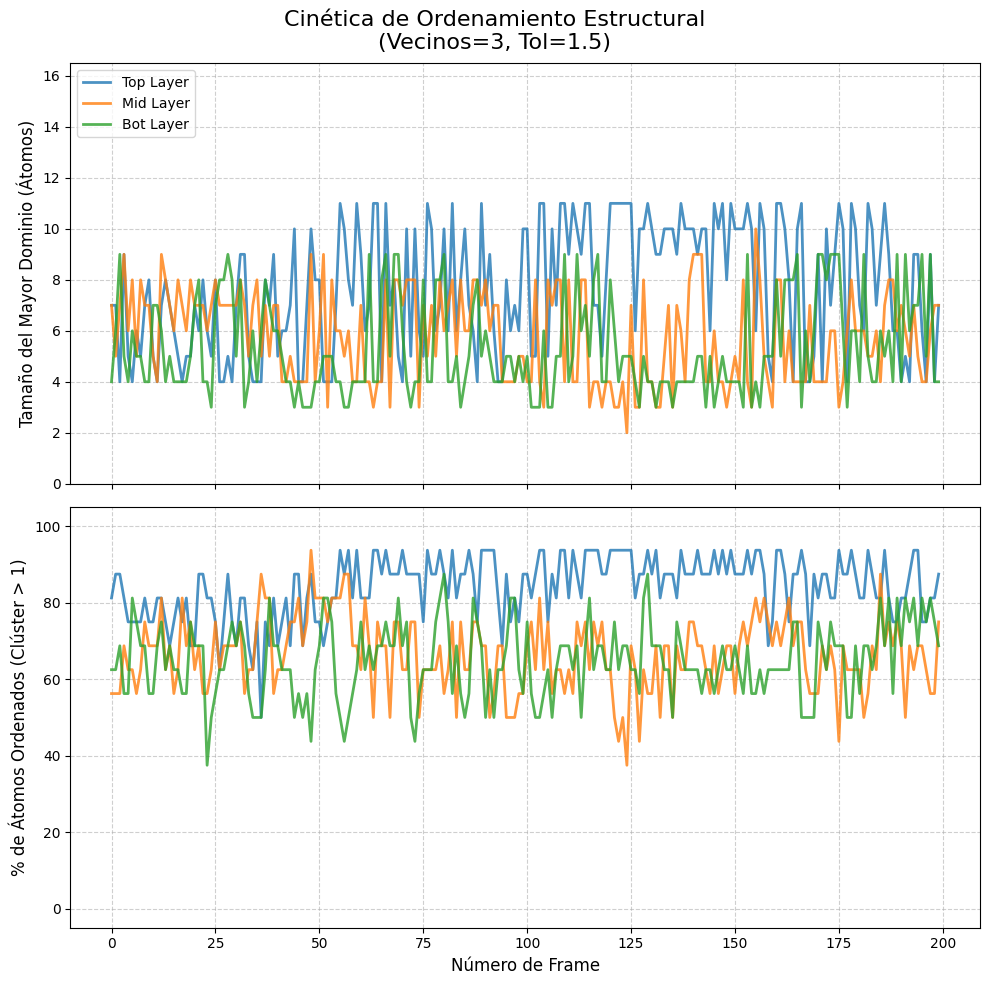

In [4]:
import numpy as np
import freud
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# ═════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════
TRAJ_FILE = "trayectoria.xyz"

INTERLAYERS = [
    (16, 'Top Layer'),
    (15, 'Mid Layer'),
    (14, 'Bot Layer'),
]

# Parámetros optimizados para monocapas de 16 átomos
NUM_NEIGHBORS = 3        
MATCH_THRESHOLD = 1.5    

# ═════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES (Lectura y Caja)
# ═════════════════════════════════════════════════════════════
def read_xyz_trajectory(filepath):
    frames = []
    with open(filepath, 'r') as f:
        while True:
            line = f.readline()
            if not line: break
            n_atoms = int(line.strip())
            comment = f.readline().strip()
            coords, types = [], []
            for _ in range(n_atoms):
                p = f.readline().split()
                coords.append([float(p[1]), float(p[2]), float(p[3])])
                types.append(int(p[4]))
            frames.append((np.array(coords), np.array(types)))
    return frames

def parse_box():
    Lx, Ly, Lz = 19.7278442383, 17.0807762146, 200.0000000000
    xy_tilt = 9.8615932465
    xy = xy_tilt / Ly if Ly else 0.0
    return freud.box.Box(Lx=Lx, Ly=Ly, Lz=Lz, xy=xy, xz=0, yz=0)

# ═════════════════════════════════════════════════════════════
# CUANTIFICACIÓN PRINCIPAL
# ═════════════════════════════════════════════════════════════
def quantify_crystallization():
    print("Leyendo trayectoria...")
    frames = read_xyz_trajectory(TRAJ_FILE)
    box = parse_box()

    # Diccionarios para guardar nuestros datos a lo largo del tiempo
    history_max_cluster = {name: [] for _, name in INTERLAYERS}
    history_ordered_frac = {name: [] for _, name in INTERLAYERS}
    frames_list = []

    print(f"Analizando {len(frames)} frames...")
    
    match_algo = freud.environment.EnvironmentCluster()
    cluster_neighbors = dict(mode='nearest', num_neighbors=NUM_NEIGHBORS, exclude_ii=True)

    for frame_idx, (coords, types) in enumerate(frames):
        frames_list.append(frame_idx)
        
        for type_id, region_name in INTERLAYERS:
            mask = (types == type_id)
            layer_coords = coords[mask].astype(np.float32)
            
            # Si por algún error la capa está vacía
            if len(layer_coords) <= NUM_NEIGHBORS:
                history_max_cluster[region_name].append(0)
                history_ordered_frac[region_name].append(0.0)
                continue
                
            # 1. Calcular entornos
            match_algo.compute(
                system=(box, layer_coords),
                threshold=MATCH_THRESHOLD,
                cluster_neighbors=cluster_neighbors,
                registration=True
            )
            cluster_indices = match_algo.cluster_idx
            
            # 2. Extraer métricas usando Counter
            counts = Counter(cluster_indices)
            
            # Métrica A: Tamaño del clúster más grande
            max_size = max(counts.values()) if counts else 0
            
            # Métrica B: Átomos en clústeres de tamaño > 1
            # (ignoramos los clústeres de tamaño 1 porque son átomos desordenados sin pareja)
            ordered_atoms = sum(size for size in counts.values() if size > 1)
            ordered_fraction = (ordered_atoms / len(layer_coords)) * 100
            
            # Guardar datos
            history_max_cluster[region_name].append(max_size)
            history_ordered_frac[region_name].append(ordered_fraction)

    # ═════════════════════════════════════════════════════════════
    # REPRESENTACIÓN GRÁFICA (PLOTTING)
    # ═════════════════════════════════════════════════════════════
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    fig.suptitle(f"Cinética de Ordenamiento Estructural\n(Vecinos={NUM_NEIGHBORS}, Tol={MATCH_THRESHOLD})", fontsize=16)
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Colores clásicos (Azul, Naranja, Verde)

    for (type_id, region_name), color in zip(INTERLAYERS, colors):
        # Gráfica Superior: Tamaño del clúster más grande
        ax1.plot(frames_list, history_max_cluster[region_name], label=region_name, color=color, linewidth=2, alpha=0.8)
        
        # Gráfica Inferior: % de átomos ordenados
        ax2.plot(frames_list, history_ordered_frac[region_name], label=region_name, color=color, linewidth=2, alpha=0.8)

    # Formato Ax1
    ax1.set_ylabel("Tamaño del Mayor Dominio (Átomos)", fontsize=12)
    ax1.set_ylim(0, 16.5) # Máximo 16 átomos
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc="upper left")

    # Formato Ax2
    ax2.set_ylabel("% de Átomos Ordenados (Clúster > 1)", fontsize=12)
    ax2.set_xlabel("Número de Frame", fontsize=12)
    ax2.set_ylim(-5, 105) # 0 a 100%
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    
    out_dir = Path("resultados_entorno")
    out_dir.mkdir(exist_ok=True)
    plt.savefig(out_dir / "cuantificacion_clusters.png", dpi=300)
    print("\n¡Listo! Revisa la imagen 'cuantificacion_clusters.png'")
    plt.show()

if __name__ == "__main__":
    quantify_crystallization()

# Analisis de cristalizacion

Para cada capa, el algoritmo de freud agrupa los átomos por similitud de entorno y luego el código calcula:

    Métrica A (Tamaño del Mayor Dominio): Revisa todos los grupos formados y se pregunta: "¿Cuál es el continente más grande de átomos perfectamente ordenados en este instante?". El valor irá de 0 a 16. Si llega a 16, significa que toda la capa es un cristal perfecto unificado.

    Métrica B (% de Átomos Ordenados): Suma todos los átomos que lograron emparejarse al menos con alguien más (clústeres de tamaño mayor a 1) y descarta a los átomos solitarios y desordenados (clústeres de tamaño 1). Luego, lo convierte en un porcentaje (0% a 100%). Esto te dice qué tan "sólida" vs "líquida/amorfa" está la capa completa.

Al terminar de procesar los 200 frames, el código usa matplotlib para dibujar una gráfica que resume toda tu simulación en una sola imagen:

    Arriba (Métrica A): Se grafican tres líneas de colores (una por capa) que suben y bajan. Si una línea sube bruscamente en el frame 50 y se queda arriba, significa que el sodio de esa capa nucleó y formó un cristal estable en ese preciso momento.

    Abajo (Métrica B): Se muestra el porcentaje de orden global. Si la capa Mid siempre está en 100% pero la capa Top fluctúa entre 20% y 50%, confirmarás matemáticamente que el confinamiento intermedio favorece el orden, mientras que las superficies exteriores son más caóticas.